In [1]:
from src.preprocessing import *
# from src.your_part_usage_example import main
from src.sdt import SDT
from src.dbdt import DBDT_SGD
from src.pdsca import DBDTComTrainer
from src.baselines import get_baseline_models
from src.evaluation import *
from hmeasure import h_score
import torch
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Data Preprocessing

- Loaded the Kaggle credit-card fraud dataset and mapped labels from {0,1} to {-1,+1}.
- Used stratified train/test and train/validation splits to preserve class imbalance.
- Standardized Amount and Time using scaler fit on train only.
- Applied `IQR` outlier filtering on training data only (Amount, Time).
- Applied `SMOTE` on filtered training data only to rebalance classes.
- Generated `t-SNE` plots before/after `SMOTE` for class-separation visualization.

sample_size: 20000


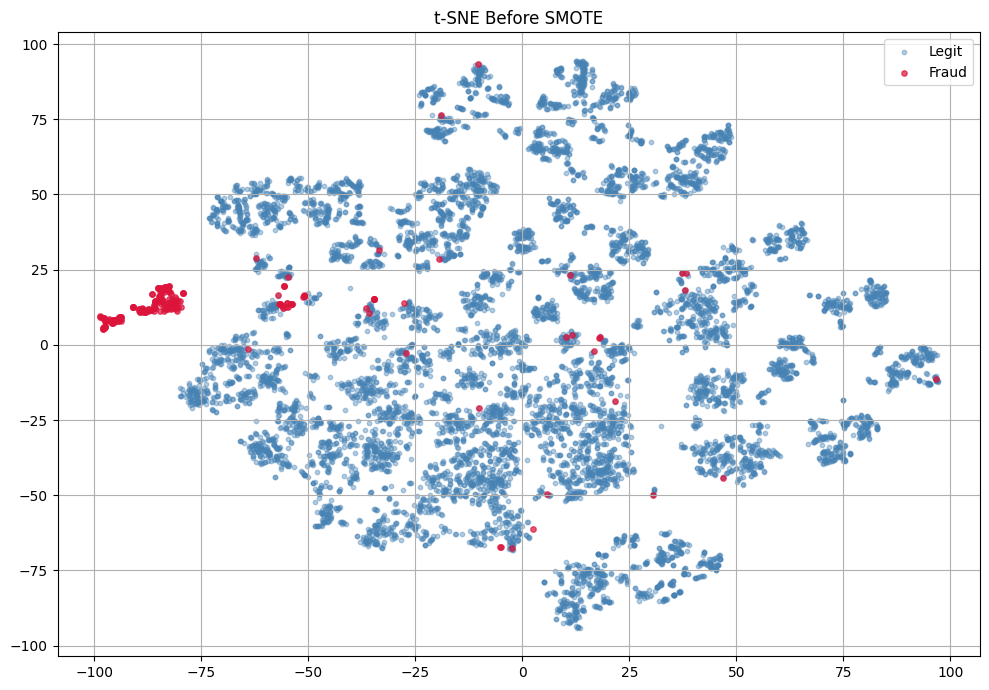

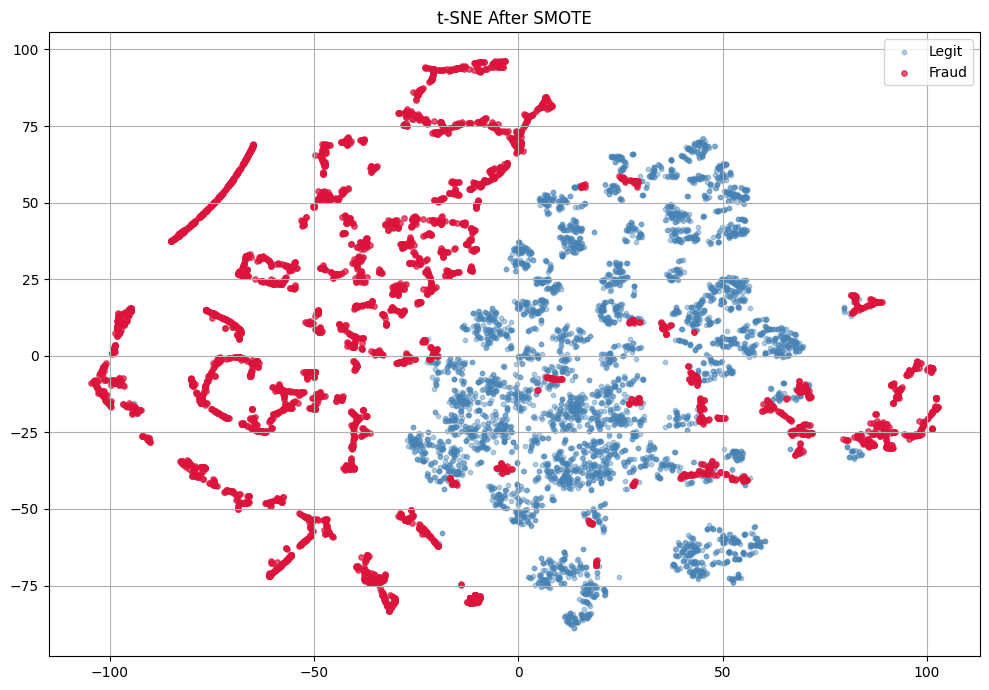

=== Dataset Size Levels ===
Full dataset          : X=284,807, y=284,807 | class={np.int64(1): 284315, np.int64(-1): 492}
Subset dataset        : X=20,000, y=20,000 | class={np.int64(1): 19508, np.int64(-1): 492}
Train split           : X=10,012, y=10,012 | class={np.int64(1): 9776, np.int64(-1): 236}
Validation split      : X=3,750, y=3,750 | class={np.int64(1): 3658, np.int64(-1): 92}
Test split            : X=5,000, y=5,000 | class={np.int64(1): 4877, np.int64(-1): 123}
Train after IQR       : X=10,012, y=10,012 | class={np.int64(1): 9776, np.int64(-1): 236}
Train after SMOTE     : X=19,552, y=19,552 | class={np.int64(1): 9776, np.int64(-1): 9776}

SMOTE growth factor   : 1.95x


In [2]:
# Mubaraq
sample_size = 20000
X, y = load_data()
X_full, y_full = X, y
import collections
# print(collections.Counter(y))
if sample_size:
    print(f'sample_size: {sample_size}')
    # separate by class
    fraud_idx = np.where(y == -1)[0]
    legit_idx = np.where(y == 1)[0]

    # take all fraud + random legit
    legit_sample = np.random.choice(legit_idx, size=sample_size - len(fraud_idx), replace=False)
    idx = np.concatenate([fraud_idx, legit_sample])
    np.random.shuffle(idx)

    X = X.iloc[idx]
    y = y[idx]
    
X_train, X_test, y_train, y_test = test_train_split(X, y)
X_train, X_val, y_train, y_val = train_valid_split(X_train, y_train)
X_train_iqr, y_train_iqr = interquatile_range(X_train, y_train)
plot_tsne(X=X_train_iqr, y=y_train_iqr, title="t-SNE Before SMOTE", sample_size=sample_size//2 if sample_size else 1000) 
unique_before, counts_before = np.unique(y_train, return_counts=True)


X_train, y_train = apply_smote(X_train_iqr, y_train_iqr) # resampled
feature_size_smote = X_train.size
# print(f"After SMOTE: {feature_size_smote}")
plot_tsne(X=X_train, y=y_train, title="t-SNE After SMOTE", sample_size=sample_size//2 if sample_size else 1000)
unique_after, counts_after = np.unique(y_train, return_counts=True)

print_dataset_size_levels(
    X_full, y_full,            # original/full before subset (replace if needed)
    X_subset=X, y_subset=y,       
    X_train=X_train_iqr, y_train=y_train_iqr,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    X_train_iqr=X_train_iqr, y_train_iqr=y_train_iqr, 
    X_train_smote=X_train, y_train_smote=y_train
)


# SDT (Mubaraq)
 
**1. Sigmoid (inner node activation)**
 
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
 
Each inner node MLP outputs a routing probability $p_i \in (0, 1)$ via sigmoid.
 
**2. Left / right path selection**
 
$$
I^l_i + I^r_i = 1
$$
 
Where $I^r_i = 1$ if $p_i > 0.5$ (go right), $I^l_i = 1$ if $p_i < 0.5$ (go left).
 
**3. Leaf node output (binary case)**
 
For binary classification with labels $y \in \{-1, +1\}$, each leaf outputs a scalar $\varphi_\ell \in \mathbb{R}$.
 
In the general multi-class case the softmax is applied:
 
$$
Q^{\ell}_k = \frac{\exp(\varphi^{\ell}_k)}{\sum_{k'} \exp(\varphi^{\ell}_{k'})}
$$
 
Where $\varphi^\ell$ is the learned parameter vector of leaf $\ell$ and $k$ indexes the class.
  
**4. Path probability**
 
$$
\pi_\ell(x \mid \Theta) = \prod_{j < \ell} d_j(x;\Theta_j)^{I^r_j} \cdot (1 - d_j(x;\Theta_j))^{I^l_j}
$$
 
Where:
- $d_j(x; \Theta_j)$ is the sigmoid output of inner node $j$ — i.e. $p_j$
- $I^r_j = 1$ if node $j$ routes right on the path to leaf $\ell$, else $0$
- $I^l_j = 1$ if node $j$ routes left on the path to leaf $\ell$, else $0$
- The product runs over all inner nodes $j$ on the root-to-leaf-$\ell$ path
 
 
**5. SDT predicted output**
 
$$
\hat{y}(x) = \sum_{\ell} \pi_\ell(x \mid \Theta) \cdot \varphi_\ell
$$
 
The final score $h(x) \in \mathbb{R}$. Prediction is the sign:
 
$$
\hat{y} = \text{sign}(h(x)) \in \{-1, +1\}
$$

**6. Tree dimensions**
 
For a tree of depth $d$:
 
$$
\text{inner nodes} = 2^d - 1 \qquad \text{leaf nodes} = 2^d
$$
 


### Test SDT

In [3]:
# This is to ensure sdt is running
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t, X_test_t, y_train_t, y_test_t=torch_cast(X_train, X_test, y_train, y_test, device) # allows for torch shaping
_, X_val_t, _, y_val_t=torch_cast(X_train, X_val, y_train, y_val, device) # allows for torch shaping

"""SDT is not evaluated in the paper. It is not trained on anything, therefore no evaluation. [untrained weights]"""
model = SDT(input_dim=30, depth=4, hidden_dim=30).to(device)
output, path_probs, node_outputs, node_reach = model.forward(X_train_t)
preds =model.predict(X_train_t)
print(preds.shape)
print(preds.unique())


torch.Size([19552])
tensor([-1.,  1.], device='cuda:0')


## Deep Boosting 
**7. Boosting exponential loss**
 
$$
L = \sum_i \exp(-y_i \cdot F(x_i))
$$

 
Where $y_i \in \{-1, +1\}$ and $F(x_i)$ is the ensemble score. Requires $\{-1, +1\}$ labels — loss is asymmetric with $\{0, 1\}$.
 
 
**8. Final ensemble prediction**
 
$$
F_T(x) = \sum_{t=1}^{T} \alpha_t \cdot h_t(x)
$$
 
Where:
- $h_t(x)$ is the output of the $t$-th SDT weak learner
- $\alpha_t$ is the boosting weight of tree $t$
- $T$ is the total number of trees
 

In [4]:

print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 4070 Laptop GPU


### Model

In [5]:
epochs = 30
batch_size = 256
T = 20
model = DBDT_SGD(T=T, input_dim=30, depth=4, hidden_dim=30, lr=0.01, device= device)


### Fit

In [6]:
## DBDT_SGD fit
h = model.fit(X_train_t,  y_train_t, epochs=epochs, batch_size=batch_size)
print(h.device)

Training DBDT: 100%|██████████| 30/30 [37:04<00:00, 74.15s/it, loss=376.5475] 

cuda


## Metrics(DBDT SGD)
Metrics include produces evaluation for:
- AUC, F1, Precision, Recall, and H-Measure.
- Visuals for Confusion matrix and ROCs

In [7]:
print(f"epochs={epochs}, batch_size={batch_size}, T={T}")

epochs=30, batch_size=256, T=20


### Train Evaluation

In [34]:
def evaluate_binary(y_true, y_scores, pos_label=-1, threshold=0.5, print_: bool = True):
    """
    y_true, y_pred: torch.Tensor or np.ndarray, values in {-1, +1}.
    pos_label: label treated as the positive class (here fraud = -1).
    """
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy().ravel()
    else:
        y_true = np.asarray(y_true).ravel()
    
    if isinstance(y_scores, torch.Tensor):
        y_scores = y_scores.detach().cpu().numpy().ravel()
    # else:
              
    
    # y_scores = np.asarray(y_scores).ravel()
    y_bin = (y_true == pos_label).astype(int)
    
    fraud_scores = -y_scores
    auc    = roc_auc_score(y_bin, fraud_scores)
    
    y_pred = np.where(fraud_scores >= threshold, pos_label, -pos_label)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[pos_label, -pos_label])
    # auc_ = ()
    
    metrics = {
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "confusion_matrix": cm,  # rows/cols: [pos_label, negative_label]
    }
    hm = h_score(y_true, y_pred)
    if print_:
        print(f"no. of samples {len(y_true)} || {dict(Counter(y_true))}")
        print(f"AUC:       {auc:.4f}")
        print(f"F1:        {f1:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"H-measure: {hm:.4f}")
    
        fpr, tpr, _ = roc_curve(y_bin, fraud_scores)
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fraud', 'Legit'])
        disp.plot(cmap='Blues')
        plt.title("Confusion Matrix")
        plt.show()
        
        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()
    return metrics

no. of samples 19552 || {np.float32(1.0): 9776, np.float32(-1.0): 9776}
AUC:       0.9976
F1:        0.9386
Precision: 0.9986
Recall:    0.8853
H-measure: 0.8183


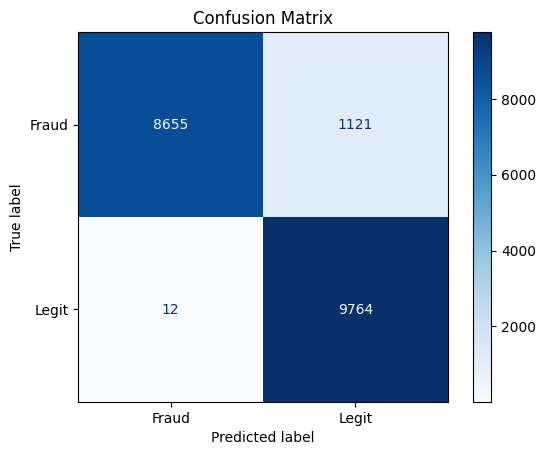

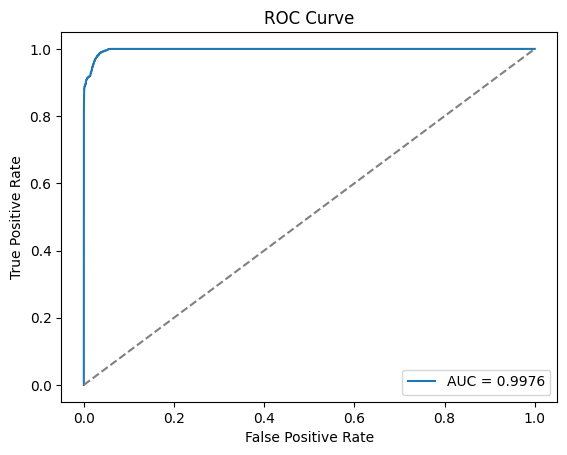

In [37]:
train_metrics = evaluate_binary(y_train_t, model.predict_score(X_train_t), threshold=0.8, print_ = True)

### Validaiton Evaluations
Using threshold optimization to get best threshold that maximizws recall (So we miss less fraud)

Best Threshold: 0.8 at recall: 0.8586956521739131
no. of samples 3750 || {np.float32(1.0): 3658, np.float32(-1.0): 92}
AUC:       0.9640
F1:        0.8634
Precision: 0.8681
Recall:    0.8587
H-measure: 0.7865


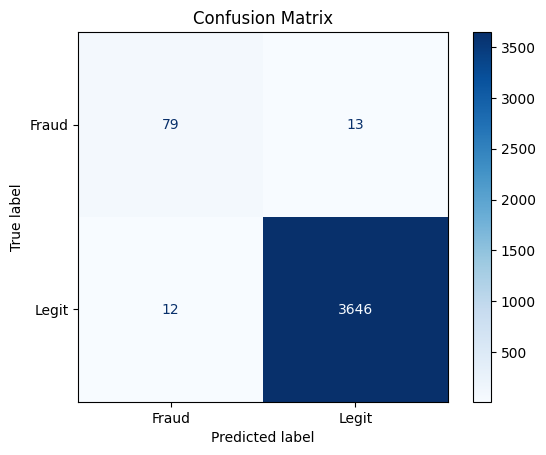

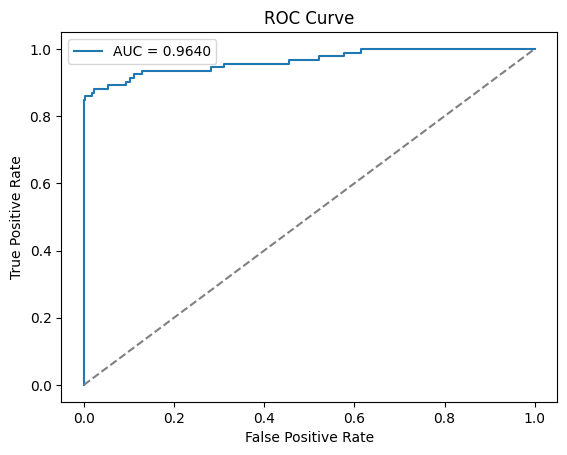

Best Threshold: 0.8 at precision: 0.9285714285714286
no. of samples 3750 || {np.float32(1.0): 3658, np.float32(-1.0): 92}
AUC:       0.9640
F1:        0.8864
Precision: 0.9286
Recall:    0.8478
H-measure: 0.8089


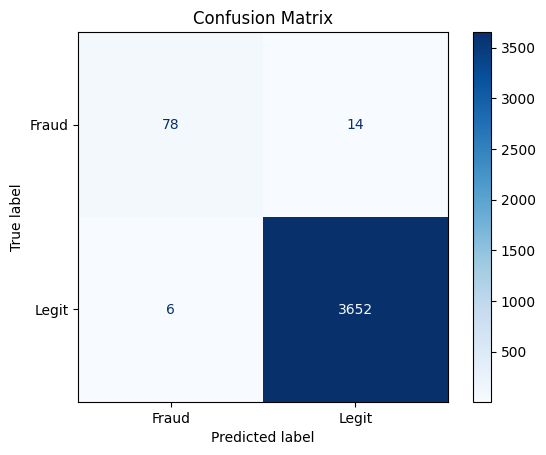

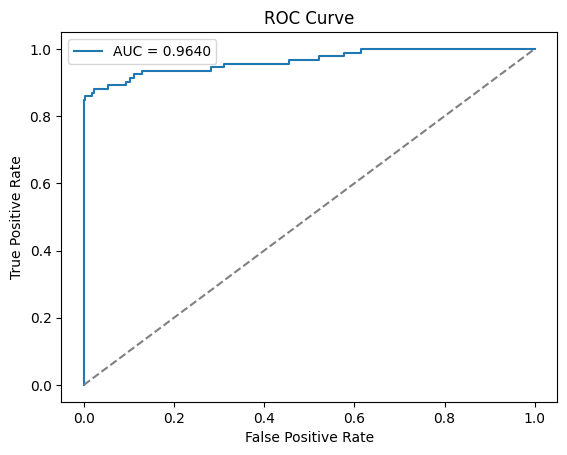

In [38]:
thresholds = [0.4 ,0.5, 0.6, 0.7, 0.8]
def threshold_optimization(metric: str = 'recall'):
    metrtics ={}
    
    for threshold in thresholds:
        val_metrics = evaluate_binary(y_val_t, model.predict_score(X_val_t), threshold=threshold, print_ = False)
        metrtics[val_metrics[metric]] = threshold

    max_metric = max(metrtics.keys())
    best_threshold = metrtics[max_metric]
    print(f"Best Threshold: {threshold} at {metric}: {max_metric}")
    # for k , v in recalls.items()
    val_metrics = evaluate_binary(y_val_t, model.predict_score(X_val_t), threshold=best_threshold)
    return best_threshold
best_threshold = threshold_optimization()
best_threshold = threshold_optimization('precision')


# best_threshold = 

### Test Evaluations

no. of samples 5000 || {np.float32(1.0): 4877, np.float32(-1.0): 123}
AUC:       0.9864
F1:        0.9106
Precision: 0.9554
Recall:    0.8699
H-measure: 0.8445


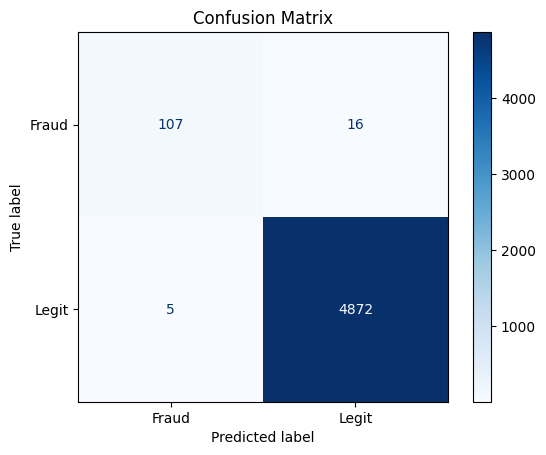

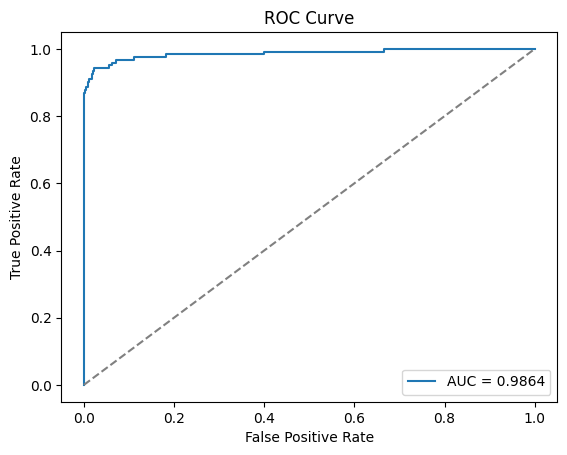

In [39]:


test_metrics = evaluate_binary(y_test_t, model.predict_score(X_test_t), threshold=best_threshold)

# DBDT-COM (Darsh)

In [40]:
trainer = DBDTComTrainer(
    model=model,
    eta1=1e-3,
    batch_size=batch_size,
    device=device,
)

trainer.fit(X_train_t, y_train_t, epochs=epochs)


Training DBDT: 100%|██████████| 30/30 [15:11<00:00, 30.39s/it]


## Evaluation

In [41]:

# Model learns fraud=-1, legit=+1.
# So raw scores are LOWER for fraud.
raw_scores = trainer.predict_scores(X_test_t)

# Flip sign so HIGHER score means fraud/positive class
fraud_scores = -raw_scores

# Convert to probabilities for H-measure / metrics
test_scores = 1 / (1 + np.exp(-fraud_scores))

y_test_bin = np.where(y_test_t.detach().cpu().numpy() == -1, 1, 0)

print("\nDBDT-Com test metrics:\n", compute_metrics(y_test_bin, test_scores))


DBDT-Com test metrics:
 FoldResult(auc=0.9759331589625103, h_measure=0.8733862192213754, f1=0.3137254901960784, precision=0.18691588785046728, recall=0.975609756097561)


## Baselines

In [42]:

baseline_models = get_baseline_models(random_state=42)
baseline_summary, _ = run_stratified_10fold_cv(baseline_models, X_train, y_train)
print("\nBaseline CV summary:\n", baseline_summary)


Baseline CV summary:
     model  auc_mean   auc_std  h_measure_mean  h_measure_std   f1_mean  \
2     mlp  0.999716  0.000264        0.996865       0.002248  0.998265   
1      rf  0.996981  0.000567        0.931269       0.008056  0.959591   
0  logreg  0.990671  0.001519        0.872585       0.009873  0.942123   

     f1_std  precision_mean  precision_std  recall_mean  recall_std  
2  0.001074        0.996639       0.001985     0.999898    0.000307  
1  0.003509        0.997463       0.001480     0.924510    0.006287  
0  0.005401        0.971989       0.007811     0.914076    0.006077  


Better than paper:
hyper parameters: T = 40; batch_size = 256; epochs = 30



AUC:       0.9719
F1:        0.8889
Precision: 0.9804
Recall:    0.8130
H-measure: 0.7991